# Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load Data

In [18]:
df = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\Hospital_Operations_Analysis\Hospital_Operations.csv")
df.head()

,Record ID,Date,Department,Employee ID,Gender,Age,Service type,Patients handled,Revenue USD,Cost USD,Waiting time,Satisfaction_score
0,1,28/05/2024,Orthopedics,E1110,Female,65,Surgery,34,4058.13,3552.31,89.2,3.39
1,2,23/06/2024,Emergency,E1459,Male,27,Therapy,12,1982.18,947.48,11.7,4.46
2,3,21/09/2024,Radiology,E1423,Male,44,Therapy,24,6210.59,4683.01,7.4,4.88
3,4,25/01/2024,Oncology,E1937,Female,26,Diagnostics,31,8408.21,4255.98,25.9,1.73
4,5,04/09/2024,Cardiology,E1048,Female,50,Diagnostics,21,3390.30,2245.66,54.7,2.16


# Data Cleaning

Checking Data types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Record ID           5000 non-null   int64  
 1   Date                5000 non-null   object 
 2   Department          5000 non-null   object 
 3   Employee ID         5000 non-null   object 
 4   Gender              5000 non-null   object 
 5   Age                 5000 non-null   int64  
 6   Service type        5000 non-null   object 
 7   Patients handled    5000 non-null   int64  
 8   Revenue USD         5000 non-null   float64
 9   Cost USD            5000 non-null   float64
 10  Waiting time        5000 non-null   float64
 11  Satisfaction_score  5000 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 468.9+ KB


Standardize Data type

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Record ID           5000 non-null   int64         
 1   Date                5000 non-null   datetime64[ns]
 2   Department          5000 non-null   object        
 3   Employee ID         5000 non-null   object        
 4   Gender              5000 non-null   object        
 5   Age                 5000 non-null   int64         
 6   Service type        5000 non-null   object        
 7   Patients handled    5000 non-null   int64         
 8   Revenue USD         5000 non-null   float64       
 9   Cost USD            5000 non-null   float64       
 10  Waiting time        5000 non-null   float64       
 11  Satisfaction_score  5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 468.9+ KB


Check Missing Values

In [12]:
df.isnull().sum()

Record ID             0
Date                  0
Department            0
Employee ID           0
Gender                0
Age                   0
Service type          0
Patients handled      0
Revenue USD           0
Cost USD              0
Waiting time          0
Satisfaction_score    0
dtype: int64

Check duplicates Values

In [14]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering (Profit)

In [32]:
df['Profit'] = df['Revenue USD'] - df['Cost USD']
df[['Department', 'Revenue USD', 'Cost USD', 'Profit']].head()

,Department,Revenue USD,Cost USD,Profit
0,Orthopedics,4058.13,3552.31,505.82
1,Emergency,1982.18,947.48,1034.70
2,Radiology,6210.59,4683.01,1527.58
3,Oncology,8408.21,4255.98,4152.23
4,Cardiology,3390.30,2245.66,1144.64


# Revenue by department

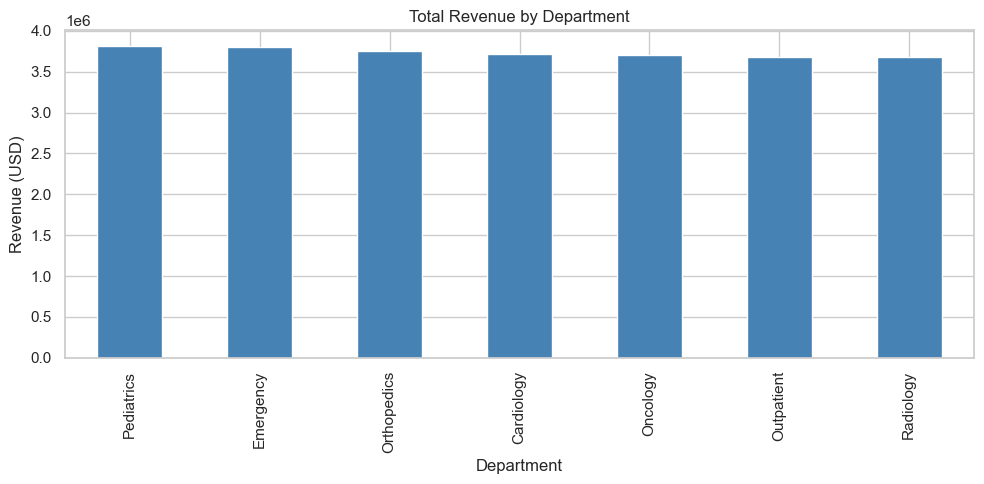

In [30]:
rev_dept = df.groupby("Department")["Revenue USD"].sum().sort_values(ascending=False)

rev_dept.plot(kind="bar", figsize=(10,5), color="steelblue", title="Total Revenue by Department")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/revenue_by_department.png")
plt.show()

# Average waiting time by department

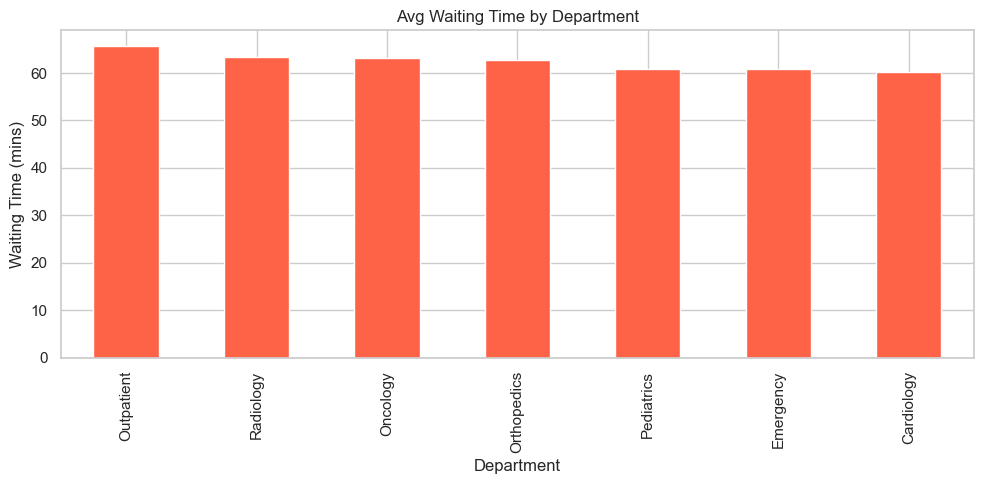

In [28]:
wait_dept = df.groupby("Department")["Waiting time"].mean().sort_values(ascending=False)

wait_dept.plot(kind="bar", figsize=(10,5), color="tomato", title="Avg Waiting Time by Department")
plt.ylabel("Waiting Time (mins)")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/waiting_time_by_department.png")
plt.show()

# Top 5 employees by patients handled

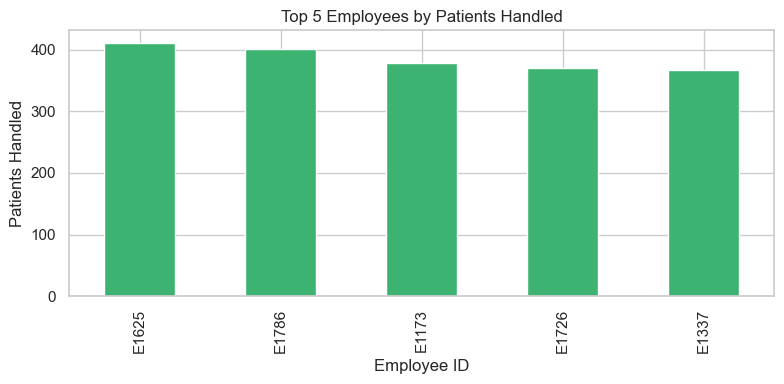

In [29]:
top_employees = df.groupby("Employee ID")["Patients handled"].sum().nlargest(5)

top_employees.plot(kind="bar", figsize=(8,4), color="mediumseagreen", title="Top 5 Employees by Patients Handled")
plt.ylabel("Patients Handled")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/top_employees.png")
plt.show()

 # Profit by department

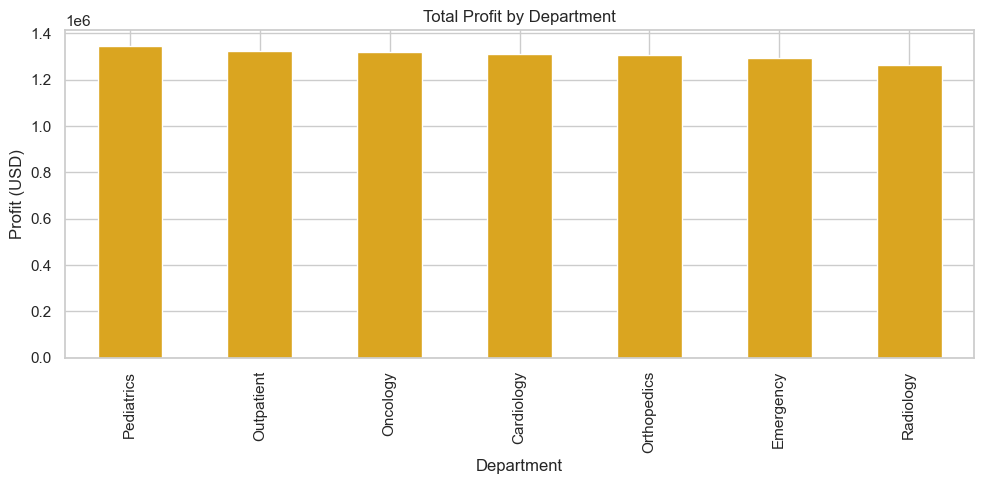

In [33]:
profit_dept = df.groupby("Department")["Profit"].sum().sort_values(ascending=False)

profit_dept.plot(kind="bar", figsize=(10,5), color="goldenrod", title="Total Profit by Department")
plt.ylabel("Profit (USD)")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/profit_by_department.png")
plt.show()

 # Revenue by service type

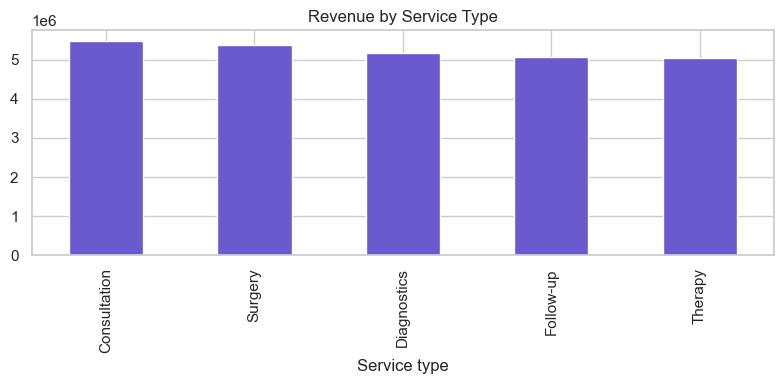

In [34]:
rev_service = df.groupby("Service type")["Revenue USD"].sum().sort_values(ascending=False)

rev_service.plot(kind="bar", figsize=(8,4), color="slateblue", title="Revenue by Service Type")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/revenue_by_service.png")
plt.show()

 # Satisfaction score by department

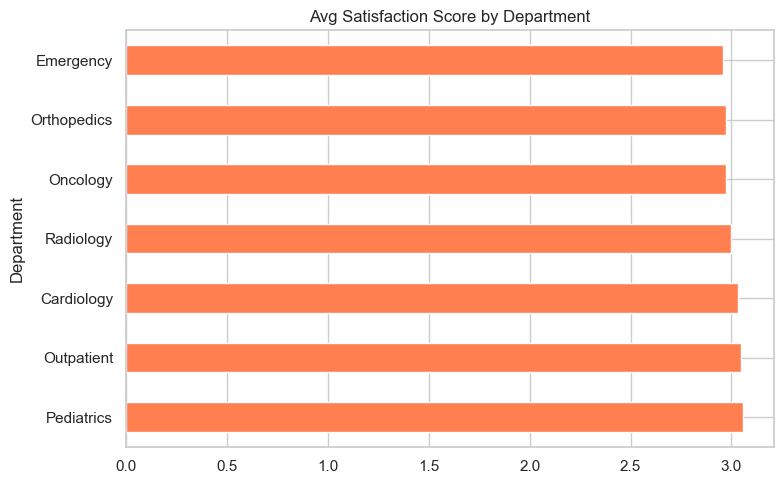

In [36]:
sat_dept = df.groupby("Department")["Satisfaction_score"].mean().sort_values(ascending=False)

sat_dept.plot(kind="barh", figsize=(8,5), color="coral", title="Avg Satisfaction Score by Department")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/satisfaction_by_department.png")
plt.show()

 # Waiting time vs satisfaction 

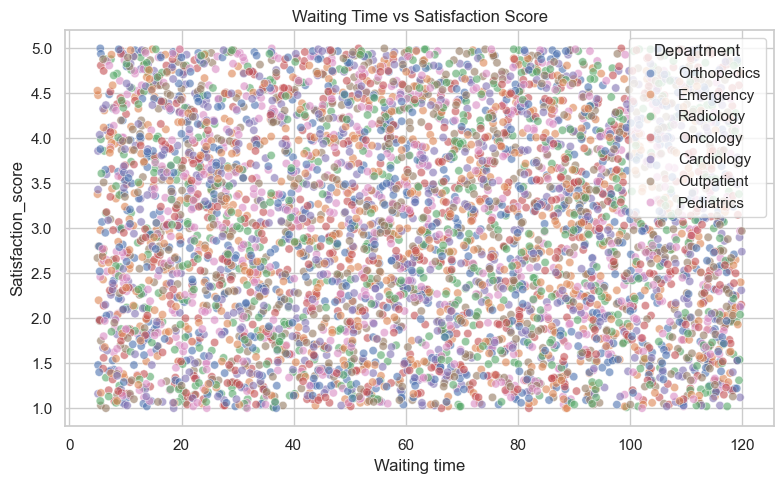

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Waiting time", y="Satisfaction_score", hue="Department", alpha=0.6)
plt.title("Waiting Time vs Satisfaction Score")
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/waiting_vs_satisfaction.png")
plt.show()

# Revenue trend over time


In [42]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

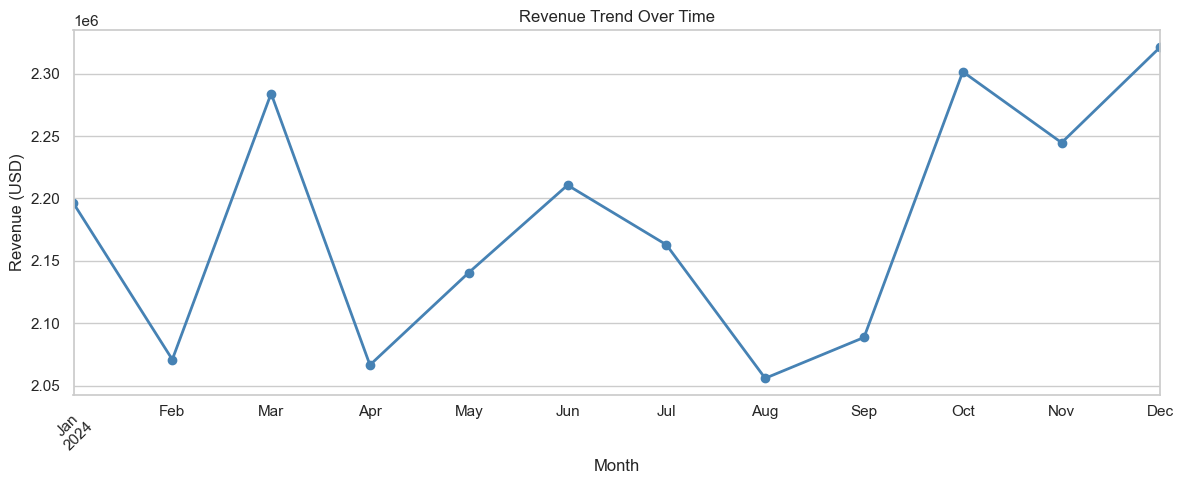

In [43]:
rev_trend = df.groupby("Month")["Revenue USD"].sum()

plt.figure(figsize=(12, 5))
rev_trend.plot(kind="line", marker="o", color="steelblue", linewidth=2, title="Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:/Users/pc/OneDrive/Desktop/Hospital_Operations_Analysis/Visuals/revenue_trend.png")
plt.show()

## Key Insights
- The hospital maintains strong profitability despite operational inefficiencies, indicating high revenue potential.
- Waiting time is the key operational bottleneck, directly impacting patient satisfaction.
- Departments like Radiology show lower profitability despite similar revenue, highlighting cost inefficiencies.
- Balanced patient distribution reduces risk, but high-volume departments require optimization. 
- Revenue trends reveal seasonal demand patterns, useful for forecasting and staffing decisions.


## Recommendations
- Optimize staffing in high-wait-time departments 
- Implement queue management or appointment systems 
- Conduct cost analysis in low-profit departments 
- Leverage seasonal trends for resource planning 
- Improve patient experience to increase satisfaction scores
